# 01 - Traffic-Object 数据准备（Kaggle）
对应项目计划书（成员A任务）：**数据集清洗、8:2固定种子划分、YOLO标注转VOC标注**
数据集：[Traffic-Object](https://www.kaggle.com/datasets/tailength/traffic-object)（24372张图，**COCO格式**，11类）
实际结构（挂载/解压后）：
- `classes.txt`  11个类别名
- `ImBalanced-Data/ImBalanced-Data/annotations/instances_{train,val,test}.json`  COCO标注
- `ImBalanced-Data/ImBalanced-Data/{train,val,test}/*.jpg`  图片
类别：Vehicle, Bus, Bicycle, Person, Engine, Truck, Tricycle, Obstacle, Pothole, Traffic Light, Traffic Sign
**Kaggle 运行前设置（右侧面板）**：
1. Accelerator 选 `GPU T4 x2`（本notebook只用CPU也能跑，但保持全程一致设置即可）
2. `Add Input` → 搜索并挂载公开数据集 `tailength/traffic-object`（无需开 Internet，无需自行上传数据）
输出（本Notebook的Output，供Notebook 02/03/04 通过 Add Input 挂载）：
- `TrafficDetYolo.zip`  清洗+划分后的YOLO格式数据（train+val合并后 8:2, seed=42）+ `data.yaml` + `test/`
- `TrafficDetVOC/`      同一划分的VOC XML格式数据（计划书"YOLO转VOC"任务产物，通用格式备份）
- `traffic_classes.json` 11类类别名


In [1]:
from pathlib import Path

DATA_SRC = Path("/kaggle/input/datasets/tailength/traffic-object")
SAMPLE = 0
if not DATA_SRC.exists():
    raise FileNotFoundError(
        f"未找到数据集: {DATA_SRC}。请检查路径是否正确或右侧是否已挂载数据集。"
    )

print(f"DATA_SRC = {DATA_SRC}")

DATA_SRC = /kaggle/input/datasets/tailength/traffic-object


# 2. 写出数据清洗+划分脚本（与仓库 scripts/prepare_dataset.py 完全一致）

In [2]:
"""
Traffic-Object 数据集预处理：COCO → YOLO 格式转换与 8:2 划分。

Pipeline:
    COCO JSON → 图片/标注校验清洗 → YOLO txt 标签 → train/val 重新划分 → 目录导出
"""
from __future__ import annotations

import json
import logging
import shutil
from collections import defaultdict
from pathlib import Path
from typing import NamedTuple

from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# ==================== 全局配置 ====================
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

DATA_SRC: Path = Path("/kaggle/input/datasets/tailength/traffic-object")
OUT_DIR: Path = Path("/kaggle/working/TrafficDetYolo")
VAL_RATIO: float = 0.2
SEED: int = 42


# ==================== 数据结构 ====================
class Sample(NamedTuple):
    """单个训练样本：图片路径 + 文件名 + YOLO 框 (cls, cx, cy, w, h)"""
    img_path: Path
    file_name: str
    boxes: list[tuple[int, float, float, float, float]]


# ==================== 元数据定位 ====================
def locate_coco_root(src: Path) -> Path:
    """定位含 annotations/instances_train.json 的 COCO 根目录"""
    hits = list(src.rglob("annotations/instances_train.json"))
    if not hits:
        raise FileNotFoundError(f"{src} 下未找到 COCO 标注文件")
    return hits[0].parent.parent


def load_class_names(src: Path) -> list[str]:
    """读取 classes.txt 中的类别名列表"""
    hits = list(src.rglob("classes.txt"))
    if not hits:
        raise FileNotFoundError(f"{src} 下未找到 classes.txt")
    with hits[0].open(encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


# ==================== 单 split 解析与清洗 ====================
def parse_split(
    coco_root: Path,
    split: str,
    name_to_idx: dict[str, int],
) -> list[Sample]:
    """
    解析并清洗指定 split 的 COCO 标注，返回 YOLO 格式样本列表。

    清洗规则：
        1. 图片损坏 / 尺寸非法 → 剔除
        2. iscrowd 标注 → 剔除
        3. bbox 宽高 ≤ 0 或归一化后越界 → 剔除
        4. 清洗后无有效框的图 → 剔除
    """
    ann_file = coco_root / "annotations" / f"instances_{split}.json"
    if not ann_file.exists():
        log.warning("标注文件不存在，跳过: %s", ann_file)
        return []

    data = json.loads(ann_file.read_text(encoding="utf-8"))

    # category_id → 连续的类别索引（与 classes.txt 对齐，避免 id 乱序串类）
    cat_id_to_idx = {c["id"]: name_to_idx[c["name"]] for c in data["categories"]}

    # 按 image_id 聚合标注，O(N) 一次扫描
    anns_by_img: dict[int, list[dict]] = defaultdict(list)
    for ann in data["annotations"]:
        anns_by_img[ann["image_id"]].append(ann)

    img_dir = coco_root / split
    samples: list[Sample] = []
    stats: dict[str, int] = defaultdict(int)

    for img_info in tqdm(data["images"], desc=f"清洗 {split}", leave=False):
        img_path = img_dir / img_info["file_name"]
        if not img_path.exists():
            stats["missing-image"] += 1
            continue

        # ---- 图片完整性校验 ----
        try:
            with Image.open(img_path) as im:
                im.verify()
            with Image.open(img_path) as im:
                w, h = im.size
        except Exception:
            stats["corrupt-image"] += 1
            continue
        if w <= 0 or h <= 0:
            stats["invalid-size"] += 1
            continue

        # ---- 标注框校验与坐标归一化 ----
        boxes: list[tuple[int, float, float, float, float]] = []
        for ann in anns_by_img[img_info["id"]]:
            if ann.get("iscrowd", 0):
                continue
            x, y, bw, bh = ann["bbox"]
            if bw <= 0 or bh <= 0:
                continue
            cx, cy = (x + bw / 2) / w, (y + bh / 2) / h
            nw, nh = bw / w, bh / h
            if nw > 1.0 or nh > 1.0:  # 越界框
                continue
            boxes.append((cat_id_to_idx[ann["category_id"]], cx, cy, nw, nh))

        if boxes:
            samples.append(Sample(img_path, img_info["file_name"], boxes))
        else:
            stats["empty-label"] += 1

    if stats:
        log.info("[%s] 剔除统计: %s", split, dict(stats))
    return samples


# ==================== YOLO 格式导出 ====================
def export_yolo(samples: list[Sample], out_dir: Path, split: str) -> dict[int, int]:
    """将样本导出为 YOLO 目录结构（images/ + labels/），返回类别计数"""
    img_dir = out_dir / split / "images"
    lbl_dir = out_dir / split / "labels"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    dist: dict[int, int] = defaultdict(int)
    for s in tqdm(samples, desc=f"导出 {split}", leave=False):
        shutil.copy2(s.img_path, img_dir / s.file_name)
        lines = [
            f"{cid} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"
            for cid, cx, cy, w, h in s.boxes
        ]
        (lbl_dir / f"{Path(s.file_name).stem}.txt").write_text(
            "\n".join(lines) + "\n", encoding="utf-8"
        )
        for cid, *_ in s.boxes:
            dist[cid] += 1
    return dict(dist)


def write_data_yaml(out_dir: Path, class_names: list[str]) -> None:
    """生成 Ultralytics YOLO 风格 data.yaml"""
    lines = [
        "path: .",
        "train: train/images",
        "val: val/images",
        "test: test/images",
        f"nc: {len(class_names)}",
        "names:",
    ] + [f"  - {n}" for n in class_names]
    (out_dir / "data.yaml").write_text("\n".join(lines) + "\n", encoding="utf-8")


# ==================== 主流程 ====================
def main() -> None:
    if not DATA_SRC.exists():
        raise FileNotFoundError(f"数据集路径不存在: {DATA_SRC}")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # 1. 元数据
    coco_root = locate_coco_root(DATA_SRC)
    class_names = load_class_names(DATA_SRC)
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    log.info("COCO 根目录: %s | 类别数: %d", coco_root, len(class_names))

    # 2. 三个 split 清洗
    train_raw = parse_split(coco_root, "train", name_to_idx)
    val_raw = parse_split(coco_root, "val", name_to_idx)
    test_set = parse_split(coco_root, "test", name_to_idx)

    # 3. 合并 train+val 后使用 sklearn 重新划分（固定种子保证可复现）
    all_data = train_raw + val_raw
    train_set, val_set = train_test_split(
        all_data,
        test_size=VAL_RATIO,
        random_state=SEED,
        shuffle=True,
        # 注：目标检测多标签场景不适合 stratify，故按随机划分
    )
    log.info("划分完成: train=%d, val=%d, test=%d",
             len(train_set), len(val_set), len(test_set))

    # 4. 导出
    dist_train = export_yolo(train_set, OUT_DIR, "train")
    export_yolo(val_set, OUT_DIR, "val")
    export_yolo(test_set, OUT_DIR, "test")

    # 5. data.yaml
    write_data_yaml(OUT_DIR, class_names)

    # 6. 训练集类别分布报告
    log.info("训练集类别分布:")
    for cid, cnt in sorted(dist_train.items(), key=lambda x: -x[1]):
        log.info("  %-16s %d", class_names[cid], cnt)

    log.info("✅ 完成，输出目录: %s", OUT_DIR.resolve())


if __name__ == "__main__":
    main()

[INFO] COCO 根目录: /kaggle/input/datasets/tailength/traffic-object/coco_split/coco_split | 类别数: 11


清洗 train:   0%|          | 0/22257 [00:00<?, ?it/s]

清洗 val:   0%|          | 0/4766 [00:00<?, ?it/s]

清洗 test:   0%|          | 0/4826 [00:00<?, ?it/s]

[INFO] 划分完成: train=21618, val=5405, test=4826


导出 train:   0%|          | 0/21618 [00:00<?, ?it/s]

导出 val:   0%|          | 0/5405 [00:00<?, ?it/s]

导出 test:   0%|          | 0/4826 [00:00<?, ?it/s]

[INFO] 训练集类别分布:
[INFO]   Traffic Light    9064
[INFO]   Traffic Sign     8600
[INFO]   Engine           6491
[INFO]   Bicycle          6455
[INFO]   Bus              5508
[INFO]   Person           5088
[INFO]   Truck            4953
[INFO]   Vehicle          3219
[INFO]   Pothole          2387
[INFO]   Obstacle         2312
[INFO]   Tricycle         583
[INFO] ✅ 完成，输出目录: /kaggle/working/TrafficDetYolo


# 3. 写出 YOLO -> VOC 转换脚本（与仓库 scripts/yolo2voc.py 完全一致）

In [3]:
"""
YOLO -> VOC(Pascal XML) 标注转换
对应计划书：成员A - YOLO标注转VOC标注脚本开发

改造版：去除自动定位与argparse，直接使用固定路径，支持Jupyter Cell直接运行
"""
from __future__ import annotations

import logging
import xml.etree.ElementTree as ET
from pathlib import Path
from shutil import copy2
from typing import NamedTuple

from PIL import Image
from tqdm.auto import tqdm

# ==================== 全局配置 ====================
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# 直接写死上一步的输出目录
YOLO_ROOT = Path("/kaggle/working/TrafficDetYolo")
VOC_OUT_DIR = Path("/kaggle/working/TrafficDetVOC")
SPLITS = ("train", "val")

# ==================== 数据结构 ====================
class VOCBox(NamedTuple):
    """VOC 格式的绝对坐标框"""
    cid: int
    xmin: int
    ymin: int
    xmax: int
    ymax: int

# ==================== 工具函数 ====================
def read_classes(yolo_root: Path) -> list[str]:
    """优先从 data.yaml 的 names 读取，读不到再找 classes.txt"""
    data_yaml = yolo_root / "data.yaml"
    if data_yaml.exists():
        names, in_names = [], False
        for ln in data_yaml.read_text(encoding="utf-8").splitlines():
            if ln.strip().startswith("names:"):
                in_names = True
                continue
            if in_names:
                s = ln.strip()
                if s.startswith("- "):
                    names.append(s[2:].strip())
                elif s:
                    break
        if names:
            return names
            
    cands = sorted(yolo_root.glob("**/classes.txt"))
    if cands:
        return [ln.strip() for ln in cands[0].read_text(encoding="utf-8").splitlines() if ln.strip()]
    
    raise FileNotFoundError(f"未在 {yolo_root} 下找到 data.yaml(names) 或 classes.txt")


def yolo_line_to_voc(cx: float, cy: float, w: float, h: float, iw: int, ih: int) -> tuple[int, int, int, int]:
    """YOLO 归一化中心坐标 -> VOC 绝对坐标（xmin, ymin, xmax, ymax）"""
    bw, bh = w * iw, h * ih
    x1, y1 = cx * iw - bw / 2.0, cy * ih - bh / 2.0
    x2, y2 = x1 + bw, y1 + bh
    
    # 边界截断，防止越界
    xmin = max(0, min(iw - 1, int(round(x1))))
    ymin = max(0, min(ih - 1, int(round(y1))))
    xmax = max(xmin + 1, min(iw, int(round(x2))))
    ymax = max(ymin + 1, min(ih, int(round(y2))))
    return xmin, ymin, xmax, ymax


def build_xml(img_name: str, size: tuple[int, int, int], objects: list[VOCBox], class_names: list[str]) -> ET.Element:
    """构建 Pascal VOC XML 树"""
    ann = ET.Element("annotation")
    ET.SubElement(ann, "folder").text = "JPEGImages"
    ET.SubElement(ann, "filename").text = img_name
    
    src = ET.SubElement(ann, "source")
    ET.SubElement(src, "database").text = "Traffic-Object(YOLO2VOC)"
    
    size_el = ET.SubElement(ann, "size")
    ET.SubElement(size_el, "width").text = str(size[0])
    ET.SubElement(size_el, "height").text = str(size[1])
    ET.SubElement(size_el, "depth").text = str(size[2])
    ET.SubElement(ann, "segmented").text = "0"
    
    for obj in objects:
        obj_el = ET.SubElement(ann, "object")
        ET.SubElement(obj_el, "name").text = class_names[obj.cid]
        ET.SubElement(obj_el, "pose").text = "Unspecified"
        ET.SubElement(obj_el, "truncated").text = "0"
        ET.SubElement(obj_el, "difficult").text = "0"
        
        bnd = ET.SubElement(obj_el, "bndbox")
        ET.SubElement(bnd, "xmin").text = str(obj.xmin)
        ET.SubElement(bnd, "ymin").text = str(obj.ymin)
        ET.SubElement(bnd, "xmax").text = str(obj.xmax)
        ET.SubElement(bnd, "ymax").text = str(obj.ymax)
        
    return ann

# ==================== 主流程 ====================
def yolo2voc(yolo_root: Path = YOLO_ROOT, out: Path = VOC_OUT_DIR, splits: tuple[str, ...] = SPLITS) -> Path:
    """YOLO 格式 -> VOC 格式转换。"""
    out.mkdir(parents=True, exist_ok=True)
    class_names = read_classes(yolo_root)
    log.info("类别数: %d | 类别: %s", len(class_names), class_names)

    jpeg_dir = out / "JPEGImages"
    ann_dir = out / "Annotations"
    sets_dir = out / "ImageSets" / "Main"
    for d in (jpeg_dir, ann_dir, sets_dir):
        d.mkdir(parents=True, exist_ok=True)

    for split in splits:
        img_dir = yolo_root / split / "images"
        lbl_dir = yolo_root / split / "labels"
        
        if not img_dir.exists():
            log.warning("缺少 %s，跳过 %s", img_dir, split)
            continue

        n_img, n_box, n_skip = 0, 0, 0
        lines: list[str] = []
        
        # 过滤出符合后缀的图片并添加进度条
        img_files = sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
        
        for img_path in tqdm(img_files, desc=f"转换 {split}", leave=False):
            lbl_path = lbl_dir / (img_path.stem + ".txt")
            if not lbl_path.exists():
                n_skip += 1
                continue

            with Image.open(img_path) as im:
                im = im.convert("RGB")
                iw, ih = im.size

            objects: list[VOCBox] = []
            for ln in lbl_path.read_text(encoding="utf-8").splitlines():
                parts = ln.split()
                if len(parts) != 5:
                    continue
                cid = int(float(parts[0]))
                cx, cy, w, h = map(float, parts[1:])
                xmin, ymin, xmax, ymax = yolo_line_to_voc(cx, cy, w, h, iw, ih)
                objects.append(VOCBox(cid, xmin, ymin, xmax, ymax))
                n_box += 1

            if not objects:
                n_skip += 1
                continue

            # 统一命名为 .jpg 到 JPEGImages
            dst_img = jpeg_dir / (img_path.stem + ".jpg")
            if img_path.suffix.lower() in (".jpg", ".jpeg"):
                copy2(img_path, dst_img)
            else:
                im.save(dst_img, "JPEG", quality=95)

            # 写出 XML
            xml_path = ann_dir / (img_path.stem + ".xml")
            ET.ElementTree(build_xml(dst_img.name, (iw, ih, 3), objects, class_names)).write(
                xml_path, encoding="utf-8", xml_declaration=True
            )
            
            lines.append(img_path.stem)
            n_img += 1

        # 写出 ImageSets 划分文件
        (sets_dir / f"{split}.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
        log.info("[%s] 图片: %d, 框: %d, 跳过: %d", split, n_img, n_box, n_skip)

    log.info("✅ 完成! VOC 根目录: %s", out.resolve())
    return out

# ==================== 直接运行 ====================
if __name__ == "__main__":
    voc_root = yolo2voc()
    print("VOC 输出目录:", voc_root)

[INFO] 类别数: 11 | 类别: ['Vehicle', 'Bus', 'Bicycle', 'Person', 'Engine', 'Truck', 'Tricycle', 'Obstacle', 'Pothole', 'Traffic Light', 'Traffic Sign']


转换 train:   0%|          | 0/21618 [00:00<?, ?it/s]

[INFO] [train] 图片: 21618, 框: 54660, 跳过: 0


转换 val:   0%|          | 0/5405 [00:00<?, ?it/s]

[INFO] [val] 图片: 5405, 框: 13557, 跳过: 0
[INFO] ✅ 完成! VOC 根目录: /kaggle/working/TrafficDetVOC


VOC 输出目录: /kaggle/working/TrafficDetVOC


共找到 27023 个 XML 标注文件，开始统计...
共计 68217 个标注框
  Traffic Light  : 11383
  Traffic Sign   : 10738
  Engine         : 8100
  Bicycle        : 8025
  Bus            : 6884
  Person         : 6410
  Truck          : 6181
  Vehicle        : 3869
  Pothole        : 3082
  Obstacle       : 2818
  Tricycle       : 727


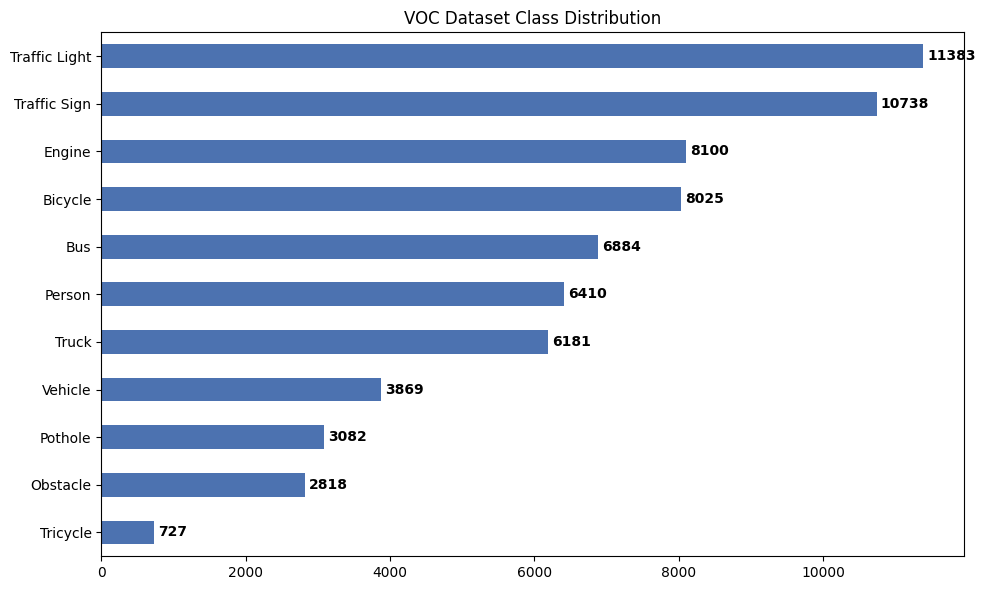

In [4]:
import glob
import xml.etree.ElementTree as ET
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

# 1. 直接扫描 VOC 的 XML 标注文件
xml_files = glob.glob("/kaggle/working/TrafficDetVOC/Annotations/*.xml")
print(f"共找到 {len(xml_files)} 个 XML 标注文件，开始统计...")

# 2. 解析 XML 提取类别名
class_counter = Counter()
for xml_path in xml_files:
    try:
        tree = ET.parse(xml_path)
        for obj in tree.getroot().findall("object"):
            name = obj.find("name").text
            class_counter[name] += 1
    except Exception:
        continue # 忽略个别损坏的 XML

# 3. 打印统计数据
total_boxes = sum(class_counter.values())
print(f"共计 {total_boxes} 个标注框")
for cls_name, count in class_counter.most_common():
    print(f"  {cls_name:15s}: {count}")

# 4. 极简绘图 (水平条形图)
ax = pd.Series(class_counter).sort_values().plot(
    kind="barh", figsize=(10, 6), title="VOC Dataset Class Distribution", color="#4C72B0"
)
ax.bar_label(ax.containers[0], padding=3, fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution_voc.png", dpi=200, bbox_inches="tight")
plt.show()

In [5]:
import shutil
import zipfile
from pathlib import Path
from tqdm.auto import tqdm

WORK = Path("/kaggle/working")
SRC_DIR = WORK / "TrafficDetYolo"
ZIP_PATH = WORK / "TrafficDetYolo.zip"

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# 1. 收集所有文件（使用 rglob 替代 os.walk）
all_files = [f for f in SRC_DIR.rglob("*") if f.is_file()]
print(f"准备打包 {len(all_files)} 个文件...")

# 2. 写入 ZIP（带进度条）
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fp in tqdm(all_files, desc="打包中", unit="file"):
        zf.write(fp, fp.relative_to(WORK))

print(f"\n✅ 打包完成: {ZIP_PATH.name} ({ZIP_PATH.stat().st_size / 1e6:.1f} MB)")
for p in sorted(WORK.iterdir()):
    print(f"{p.name}{'/' if p.is_dir() else ''}")

准备打包 63699 个文件...


打包中:   0%|          | 0/63699 [00:00<?, ?file/s]


✅ 打包完成: TrafficDetYolo.zip (5800.7 MB)
TrafficDetVOC/
TrafficDetYolo/
TrafficDetYolo.zip
__notebook__.ipynb
class_distribution_voc.png
